# МИДТЕРМ 2: Fashion-MNIST сурет классификациясы

**Тақырып:** Neural Network / Deep Learning project  
**Мақсат:** Fashion-MNIST dataset бойынша киім суреттерін 10 класқа классификациялау.

Бұл notebook ішінде:

- dataset жүктеледі және сипатталады;
- EDA жасалады;
- preprocessing орындалады;
- 2 нейрондық желі оқытылады: MLP және CNN;
- модельдер accuracy, loss, confusion matrix және classification report арқылы салыстырылады.

## Dataset туралы

- **Dataset:** Fashion-MNIST
- **Source:** Zalando Research
- **Official GitHub:** https://github.com/zalandoresearch/fashion-mnist
- **Kaggle:** https://www.kaggle.com/datasets/zalando-research/fashionmnist
- **Жүктеу тәсілі:** `keras.datasets`, `sklearn.datasets` немесе `seaborn.load_dataset` қолданылмайды. Dataset official GitHub raw `.gz` файлдарынан жүктеліп, IDX форматынан оқылады.
- **Training set:** 60 000 image
- **Test set:** 10 000 image
- **Image size:** 28x28 grayscale
- **Classes:** 10 fashion categories

Fashion-MNIST суреттері кіші болғандықтан, midterm project үшін өте ыңғайлы: тез оқытылады, бірақ CNN мен MLP арасындағы айырмашылықты жақсы көрсетеді.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gzip
import json
import struct
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid")
keras.utils.set_random_seed(42)

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
DATA_DIR = PROJECT_DIR / "data" / "raw"
for path in [FIGURES_DIR, MODELS_DIR, RESULTS_DIR, DATA_DIR]:
    path.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

DATASET_URLS = {
    "train_images": "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/train-images-idx3-ubyte.gz",
    "train_labels": "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/train-labels-idx1-ubyte.gz",
    "test_images": "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/t10k-labels-idx1-ubyte.gz",
}

EPOCHS = 3
BATCH_SIZE = 128
print("TensorFlow version:", tf.__version__)
print("Project directory:", PROJECT_DIR)

TensorFlow version: 2.21.0
Project directory: C:\Users\Admin\Documents\Codex\2026-06-01\2-17-neural-network-deep-learning\outputs\fashion_mnist_deep_learning


## 1. Dataset жүктеу

In [2]:
def download_file(url, output_path):
    if output_path.exists():
        return
    print(f"Downloading {output_path.name}...")
    urllib.request.urlretrieve(url, output_path)


def read_idx_images(path):
    with gzip.open(path, "rb") as f:
        magic, count, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image file magic number in {path}: {magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(count, rows, cols)


def read_idx_labels(path):
    with gzip.open(path, "rb") as f:
        magic, count = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label file magic number in {path}: {magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(count)


dataset_files = {
    name: DATA_DIR / url.rsplit("/", 1)[-1]
    for name, url in DATASET_URLS.items()
}

for name, url in DATASET_URLS.items():
    download_file(url, dataset_files[name])

x_train = read_idx_images(dataset_files["train_images"])
y_train = read_idx_labels(dataset_files["train_labels"])
x_test = read_idx_images(dataset_files["test_images"])
y_test = read_idx_labels(dataset_files["test_labels"])

print("Train images:", x_train.shape)
print("Train labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())

Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Pixel value range: 0 to 255


## 2. EDA: деректерді зерттеу

In [3]:
class_counts = pd.Series(y_train).value_counts().sort_index()
class_df = pd.DataFrame(
    {
        "class_id": class_counts.index,
        "class_name": [CLASS_NAMES[i] for i in class_counts.index],
        "count": class_counts.values,
    }
)
class_df

,class_id,class_name,count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


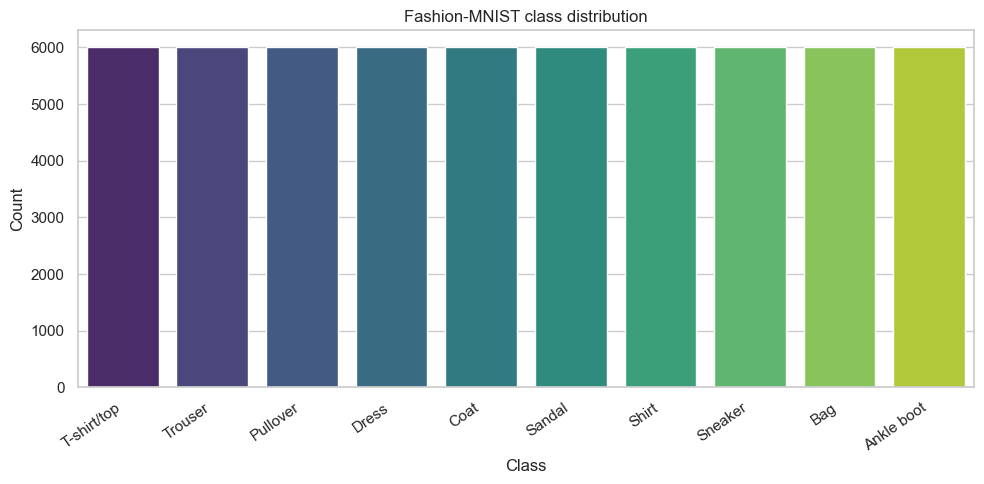

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=class_df,
    x="class_name",
    y="count",
    hue="class_name",
    palette="viridis",
    legend=False,
)
plt.title("Fashion-MNIST class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=160)
plt.show()

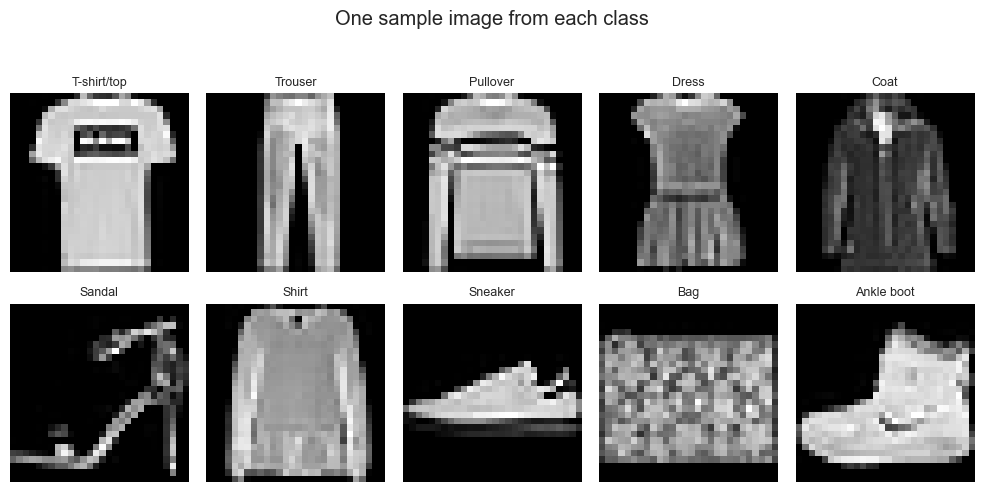

In [5]:
plt.figure(figsize=(10, 5))
for class_id, class_name in enumerate(CLASS_NAMES):
    idx = np.where(y_train == class_id)[0][0]
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(class_name, fontsize=9)
    plt.axis("off")
plt.suptitle("One sample image from each class", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_images.png", dpi=160)
plt.show()

,metric,value
0,min,0.000000
1,max,255.000000
2,mean,72.940352
3,std,90.021182


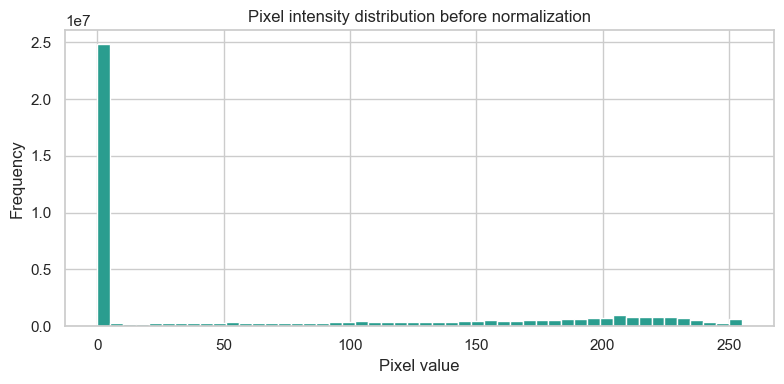

In [6]:
pixel_stats = pd.DataFrame(
    {
        "metric": ["min", "max", "mean", "std"],
        "value": [x_train.min(), x_train.max(), x_train.mean(), x_train.std()],
    }
)
display(pixel_stats)

plt.figure(figsize=(8, 4))
plt.hist(x_train.flatten(), bins=50, color="#2a9d8f")
plt.title("Pixel intensity distribution before normalization")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pixel_distribution.png", dpi=160)
plt.show()

## 3. Preprocessing

Алдын ала өңдеу қадамдары:

- pixel мәндерін `0..255` аралығынан `0..1` аралығына normalization жасау;
- training set ішінен validation set бөлу;
- MLP үшін суреттерді 784 өлшемді vector-ға айналдыру;
- CNN үшін channel dimension қосу: `(28, 28, 1)`.

In [7]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

x_train_part, x_val_part, y_train_part, y_val_part = train_test_split(
    x_train_norm,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train,
)

x_train_mlp = x_train_part.reshape(-1, 28 * 28)
x_val_mlp = x_val_part.reshape(-1, 28 * 28)
x_test_mlp = x_test_norm.reshape(-1, 28 * 28)

x_train_cnn = x_train_part[..., np.newaxis]
x_val_cnn = x_val_part[..., np.newaxis]
x_test_cnn = x_test_norm[..., np.newaxis]

print("MLP train shape:", x_train_mlp.shape)
print("CNN train shape:", x_train_cnn.shape)
print("Validation labels:", y_val_part.shape)

MLP train shape: (54000, 784)
CNN train shape: (54000, 28, 28, 1)
Validation labels: (6000,)


## 4. Model 1: MLP neural network

In [8]:
def build_mlp_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(784,)),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.20),
            layers.Dense(10, activation="softmax"),
        ],
        name="mlp_model",
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

mlp_model = build_mlp_model()
mlp_model.summary()

Model: "mlp_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model 2: CNN neural network

In [9]:
def build_cnn_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(28, 28, 1)),
            layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=2),
            layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=2),
            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(10, activation="softmax"),
        ],
        name="cnn_model",
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

cnn_model = build_cnn_model()
cnn_model.summary()

Model: "cnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Модельдерді оқыту

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True,
)

history_mlp = mlp_model.fit(
    x_train_mlp,
    y_train_part,
    validation_data=(x_val_mlp, y_val_part),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/3


  1/422 ━━━━━━━━━━━━━━━━━━━━ 5:07 731ms/step - accuracy: 0.1016 - loss: 2.4259

 14/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2948 - loss: 1.9653    

 27/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3834 - loss: 1.7219

 41/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4414 - loss: 1.5598

...

371/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8539 - loss: 0.4013

388/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8540 - loss: 0.4010

404/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8541 - loss: 0.4008

420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8542 - loss: 0.4005

422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8568 - loss: 0.3934 - val_accuracy: 0.8805 - val_loss: 0.3300


In [11]:
history_cnn = cnn_model.fit(
    x_train_cnn,
    y_train_part,
    validation_data=(x_val_cnn, y_val_part),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/3


  1/422 ━━━━━━━━━━━━━━━━━━━━ 7:18 1s/step - accuracy: 0.0859 - loss: 2.3017

  3/422 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.1176 - loss: 2.2631

  5/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.1496 - loss: 2.2180

  8/422 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.1944 - loss: 2.1417

...

413/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8866 - loss: 0.3071

416/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8866 - loss: 0.3070

419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8866 - loss: 0.3069

422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8867 - loss: 0.3069

422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8907 - loss: 0.2968 - val_accuracy: 0.9113 - val_loss: 0.2485


## 7. Модель сапасын бағалау және салыстыру

In [12]:
def evaluate_model(model, x_test_model, model_name):
    test_loss, test_accuracy = model.evaluate(x_test_model, y_test, verbose=0)
    y_pred = np.argmax(model.predict(x_test_model, verbose=0), axis=1)

    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(RESULTS_DIR / f"{model_name}_classification_report.csv")

    model.save(MODELS_DIR / f"{model_name}.keras")

    return {
        "model": model_name,
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy),
        "parameters": int(model.count_params()),
    }, report_df, y_pred


mlp_metrics, mlp_report, y_pred_mlp = evaluate_model(mlp_model, x_test_mlp, "mlp")
cnn_metrics, cnn_report, y_pred_cnn = evaluate_model(cnn_model, x_test_cnn, "cnn")

comparison_df = pd.DataFrame([mlp_metrics, cnn_metrics]).sort_values(
    "test_accuracy", ascending=False
)
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)

with open(RESULTS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump([mlp_metrics, cnn_metrics], f, indent=2)

comparison_df

,model,test_loss,test_accuracy,parameters
1,cnn,0.281395,0.8970,421642
0,mlp,0.376884,0.8643,235146


In [13]:
print("MLP classification report")
display(mlp_report.round(3))

print("CNN classification report")
display(cnn_report.round(3))

MLP classification report


,precision,recall,f1-score,support
T-shirt/top,0.851,0.755,0.800,1000.000
Trouser,0.990,0.958,0.974,1000.000
Pullover,0.766,0.785,0.775,1000.000
Dress,0.776,0.924,0.844,1000.000
Coat,0.775,0.764,0.769,1000.000
Sandal,0.977,0.944,0.960,1000.000
Shirt,0.681,0.641,0.660,1000.000
Sneaker,0.925,0.948,0.936,1000.000
Bag,0.972,0.970,0.971,1000.000
Ankle boot,0.941,0.954,0.947,1000.000


CNN classification report


,precision,recall,f1-score,support
T-shirt/top,0.831,0.847,0.839,1000.000
Trouser,0.994,0.975,0.984,1000.000
Pullover,0.843,0.831,0.837,1000.000
Dress,0.851,0.941,0.894,1000.000
Coat,0.824,0.835,0.830,1000.000
Sandal,0.976,0.981,0.979,1000.000
Shirt,0.740,0.664,0.700,1000.000
Sneaker,0.944,0.965,0.955,1000.000
Bag,0.984,0.976,0.980,1000.000
Ankle boot,0.975,0.955,0.965,1000.000


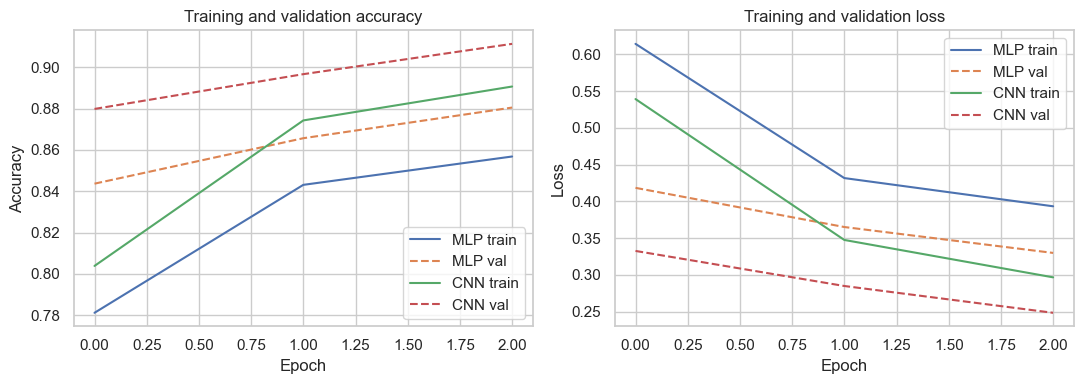

In [14]:
histories = {"MLP": history_mlp, "CNN": history_cnn}

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history["accuracy"], label=f"{name} train")
    plt.plot(history.history["val_accuracy"], linestyle="--", label=f"{name} val")
plt.title("Training and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history["loss"], label=f"{name} train")
    plt.plot(history.history["val_loss"], linestyle="--", label=f"{name} val")
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_history.png", dpi=160)
plt.show()

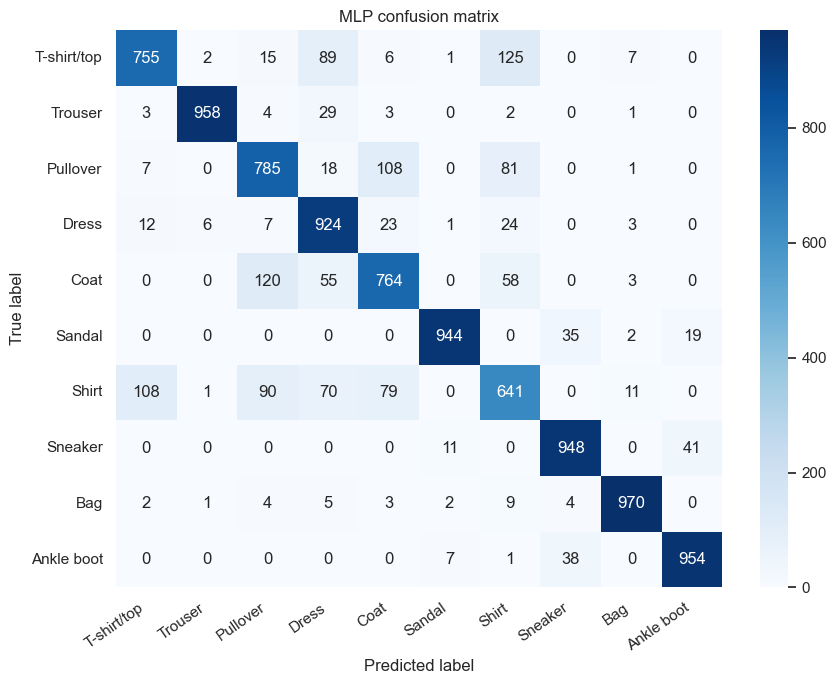

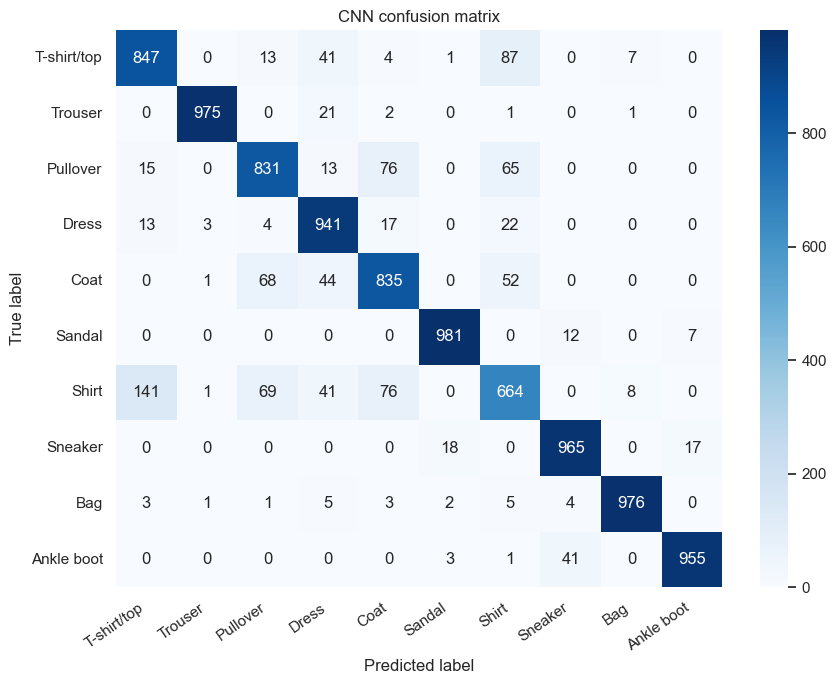

In [15]:
def show_confusion_matrix(y_true, y_pred, title, filename):
    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=160)
    plt.show()


show_confusion_matrix(y_test, y_pred_mlp, "MLP confusion matrix", "mlp_confusion_matrix.png")
show_confusion_matrix(y_test, y_pred_cnn, "CNN confusion matrix", "cnn_confusion_matrix.png")

## 8. Қорытынды

Бұл project Fashion-MNIST dataset арқылы image classification міндетін шешеді. MLP моделі базалық neural network ретінде алынды, ал CNN моделі суреттегі локалды pattern-дерді convolution қабаттары арқылы үйренеді.

Күтілетін нәтиже бойынша CNN accuracy көрсеткіші MLP-ден жоғары болады, себебі CNN суреттің кеңістіктік құрылымын сақтап өңдейді. MLP болса, суретті бір ұзын vector ретінде қарайды.

**Жоба нәтижелері сақталған орындар:**

- `figures/` - EDA және model evaluation графиктері;
- `results/` - metrics және classification reports;
- `models/` - оқытылған Keras модельдері.